# Ejercicio: simular y visualizar GPs

El objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de _machine learning_ (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos las imágenes vistas en las diapositivas.

**Nota:** Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Igual que con el PAS, tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

In [2]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utiliza la función `np.random.multivariate_normal` (busca en internet cómo usarla).

Además, visualiza el resultado obtenido, así como su shape.

In [3]:
# COMPLETAR!

vector_medias = np.zeros(3)
matriz_covarianzas = np.eye(3)
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 0.55979395 -2.01756627 -1.53007637]
 [ 0.58215644 -0.73467884 -1.79494035]
 [ 0.52951502 -1.44086247  0.597248  ]
 [ 1.11168505  1.09443223  0.27826958]
 [ 0.65502653 -0.8351125   2.43484939]
 [-0.33313042  1.73540069 -0.00276521]
 [ 0.58257959 -0.02642291  1.24127602]
 [-0.3974353  -0.9463674  -0.56915391]
 [ 0.3380886  -0.35766039 -1.5749594 ]
 [-1.3493443   0.20874477  0.81599751]
 [-1.30699137  0.18458088  0.28916089]
 [-0.14886632  0.21033314  0.65641687]
 [-1.18205691  0.33641128 -0.44525979]
 [-1.28524634 -1.14553413 -0.34776755]
 [ 0.06829131 -0.26866193 -0.10076423]
 [ 0.22047911 -1.15352906 -1.05936087]
 [ 0.07831223  0.08255278 -0.07282494]
 [ 0.31830303  1.95722471  0.09760328]
 [ 0.67452206 -0.30625964  0.06637023]
 [ 0.34849705  1.43557531  0.21415052]
 [-0.07024569 -0.1052499   1.63725139]
 [-0.88190897 -0.90434474  1.36103088]
 [-0.19117286  0.70031022 -0.1856165 ]
 [-0.83372311  0.88338959 -1.02221081]
 [-1.69246657  0.45502647 -0.62457232

Haz ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag` para crear la matriz diagonal.

¿Qué diferencias esperarías ver en las muestras obtenidas?


In [4]:
# COMPLETAR!

vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1,10,100])
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-1.51553444e+00  8.71869780e+00  2.12850429e+01]
 [ 4.35707529e-01  3.97145512e+00  5.34402841e+00]
 [ 8.96065692e-01  2.27791648e+00 -1.08736522e+01]
 [ 2.86241077e-01  9.84075222e-01 -1.50456986e+00]
 [-2.00543949e+00  1.62199856e+00 -5.29885167e+00]
 [-4.83203653e-01  7.89185786e-01 -1.08980013e+01]
 [ 1.34084272e+00 -4.02356748e+00 -2.71923063e+01]
 [-1.54297895e+00  5.44108160e-01 -1.39166873e+01]
 [-7.43465872e-01  2.37758816e+00 -7.11393308e+00]
 [-9.73273520e-01 -1.69041495e+00 -3.58522241e-01]
 [-3.93852141e-01  2.32549313e+00 -8.39875855e+00]
 [ 1.11854891e-01  4.69932598e+00 -8.42581219e+00]
 [ 8.92273323e-01 -3.46468214e+00  1.57218485e+01]
 [-2.65682019e-01  2.69131748e+00 -2.95498612e+00]
 [-1.17661365e+00  3.35607993e+00 -9.57364257e+00]
 [-1.58230241e-01 -7.56611061e-01  3.53341539e+00]
 [ 1.14053083e+00  6.08804299e+00  1.14741428e+00]
 [-1.68141621e-01  1.55551011e+00  7.00325374e+00]
 [-1.18913610e-02  1.63027646e-01  6.30198689e+00]
 [ 3

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular de un GP con kernel RBF. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función). Todo ello necesita del concepto de _clases_, algo que (creo) no se estudia en el grado en matemáticas.

Definimos la función principal:

In [5]:
# COMPLETAR

def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simular un GP con kernel RBF.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """

  # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar np.zeros_like
  vector_medias = np.zeros_like(t)

  # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la vectorización de numpy y en particular la idea de broadcasting que se comentó en la intro a numpy.
  dist_t = t - t[:,np.newaxis]
  matriz_covs = sigma_sq * np.exp(-0.5*(dist_t/lengthscale)**2)

  # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
  samples =np.random.multivariate_normal(vector_medias,matriz_covs,num_samples)

  return samples

Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62.

Para ello, genera las trayectorias con la función recién definida, `simular_GP_RBF`, y píntalas con `plt.plot`

Opcional: si quieres tener diferentes ejes (subplots) en la misma figura, como se hace en las diapositivas 59 y 62, puedes mirar cómo usar `plt.subplots`.

In [6]:
# COMPLETAR (PARA LA DIAPOSITIVA 59)

# Para generar el grid, mira la función np.linspace
n=1000
x=np.linspace(0,5,n)

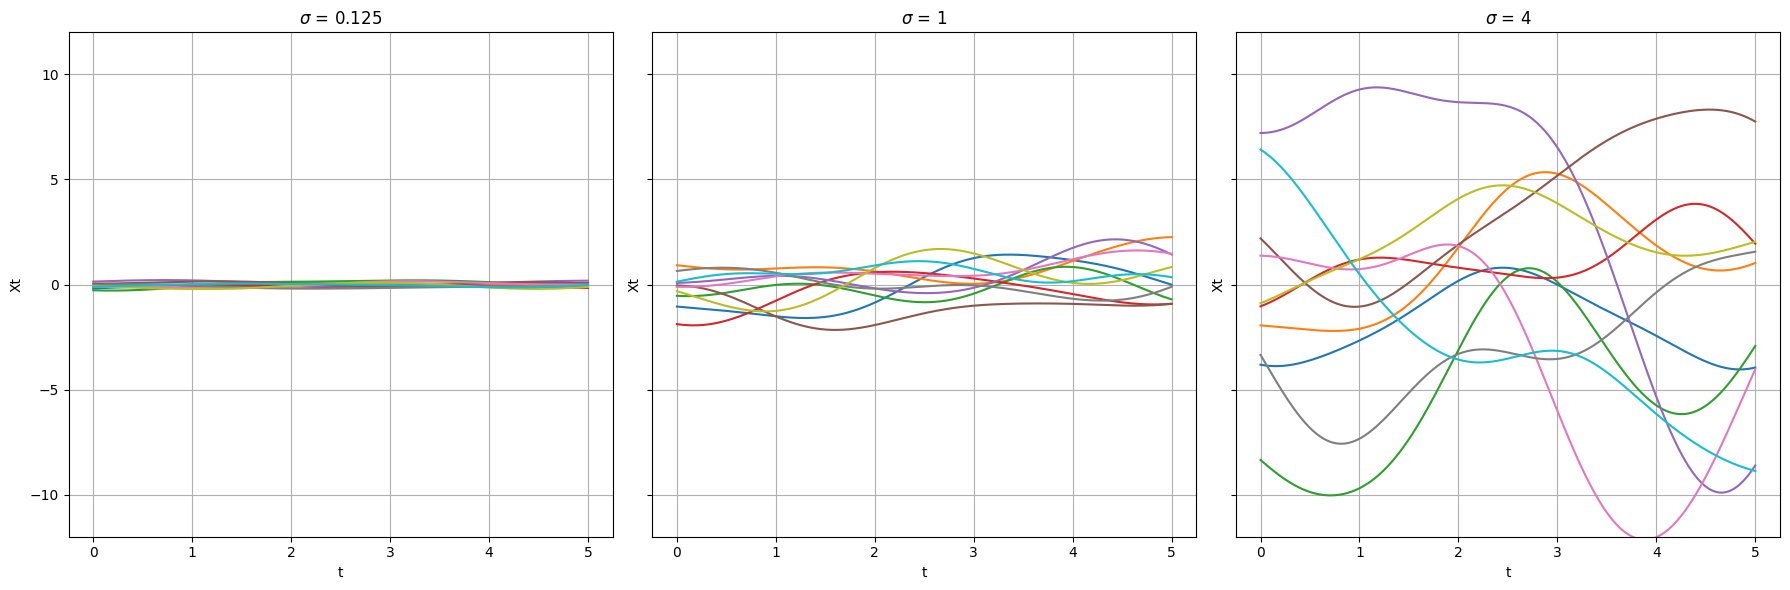

In [7]:
graficasfig, axs = plt.subplots(1,3,figsize=(18, 6), sharey=True)

lengthscale = 1
sigma_values = [0.125, 1, 4]

for i, sigma in enumerate(sigma_values):
  samples = simular_GP_RBF(x, sigma_sq=sigma**2, lengthscale=lengthscale, num_samples=10)
  for j in range(10):
    axs[i].plot(x, samples[j])
  axs[i].set_title(rf'$σ$ = {sigma}')
  axs[i].set_ylabel('Xt')
  axs[i].set_xlabel('t')
  axs[i].grid(True)

axs[0].set_ylim(-12, 12)

plt.tight_layout()
plt.show()

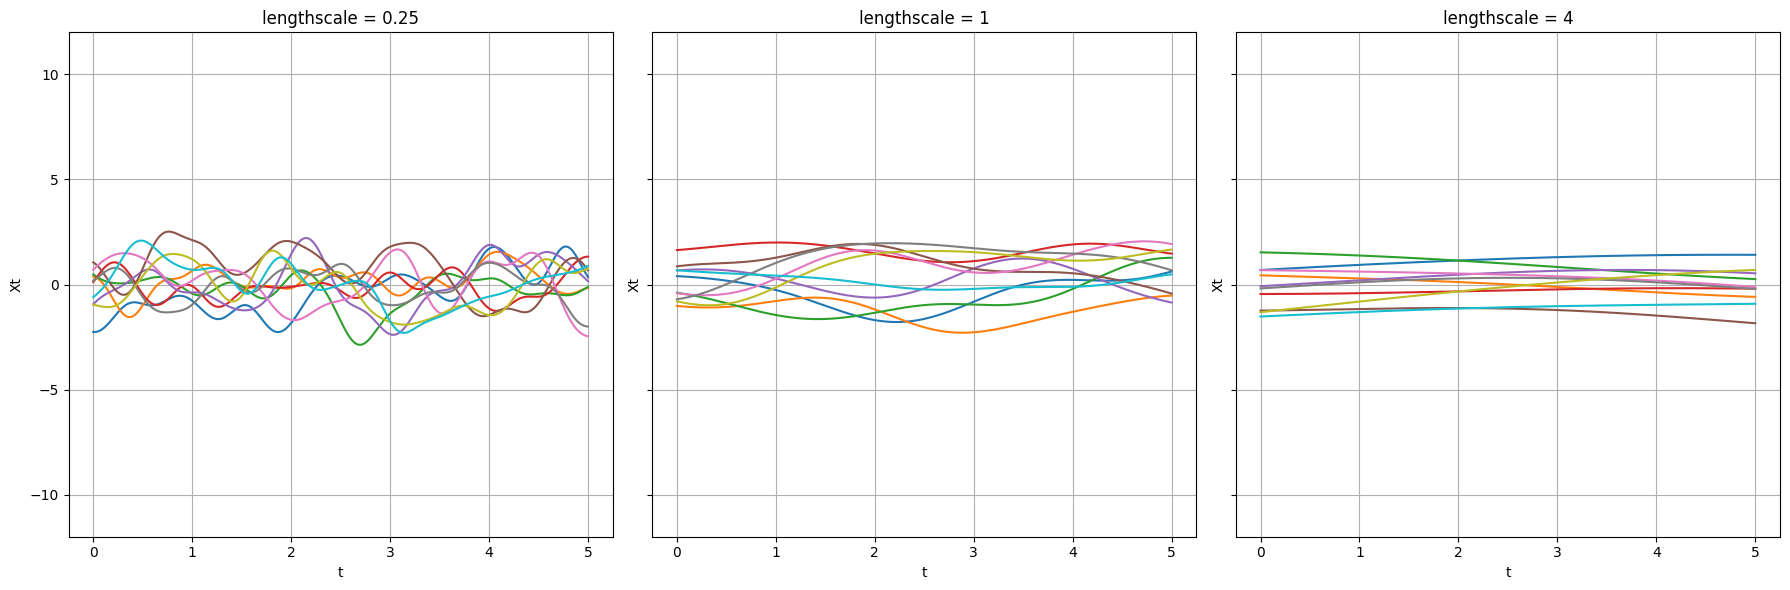

In [8]:
# COMPLETAR (PARA LA DIAPOSITIVA 62)
graficasfig, axs = plt.subplots(1,3,figsize=(18, 6), sharey=True)

sigma_sq = 1
length_values = [0.25, 1, 4]

for i, l in enumerate(length_values):
  samples = simular_GP_RBF(x, sigma_sq=sigma_sq, lengthscale=l, num_samples=10)
  for j in range(10):
    axs[i].plot(x, samples[j])
  axs[i].set_title(rf'lengthscale = {l}')
  axs[i].set_ylabel('Xt')
  axs[i].set_xlabel('t')
  axs[i].grid(True)

axs[0].set_ylim(-12, 12)

plt.tight_layout()
plt.show()

## 3. Simular un GP con kernel periódico

En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular de un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [9]:
# COMPLETAR

def simular_GP_periodic(t, sigma_sq=1, lengthscale=1, period=1, num_samples=1):
  """
  Simular un GP con kernel periódico.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  period: parámetro de periodicidad. Float
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """

  # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar np.zeros_like
  vector_medias = np.zeros_like(t)

  # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la vectorización de numpy y en particular la idea de broadcasting que se comentó en la intro a numpy.
  dist_t = t - t[:,np.newaxis]
  matriz_covs = sigma_sq * np.exp(-(2/lengthscale)*(np.sin((math.pi*dist_t)/period))**2)

  # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
  samples =np.random.multivariate_normal(vector_medias,matriz_covs,num_samples)

  return samples

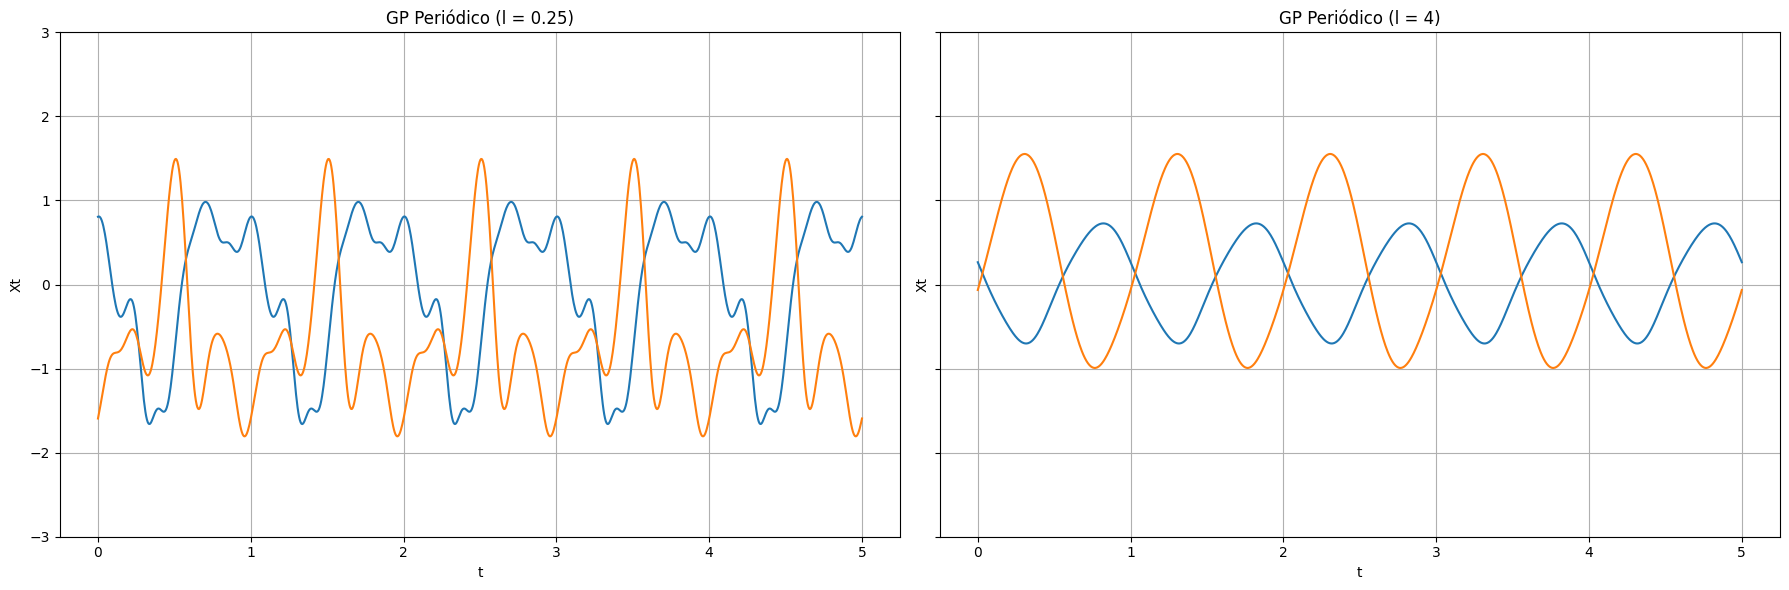

In [10]:
# COMPLETAR (PARA LA DIAPOSITIVA 72)
graficasfig, axs = plt.subplots(1,2,figsize=(18, 6), sharey=True)

period = 1
sigma_sq = 1
length_values = [0.25, 4]

for i, l in enumerate(length_values):
  samples = simular_GP_periodic(x, sigma_sq=sigma_sq, lengthscale=l, period=period, num_samples=2)
  for j in range(2):
    axs[i].plot(x, samples[j])
  axs[i].set_title(rf'GP Periódico (l = {l})')
  axs[i].set_ylabel('Xt')
  axs[i].set_xlabel('t')
  axs[i].grid(True)

axs[0].set_ylim(-3, 3)

plt.tight_layout()
plt.show()

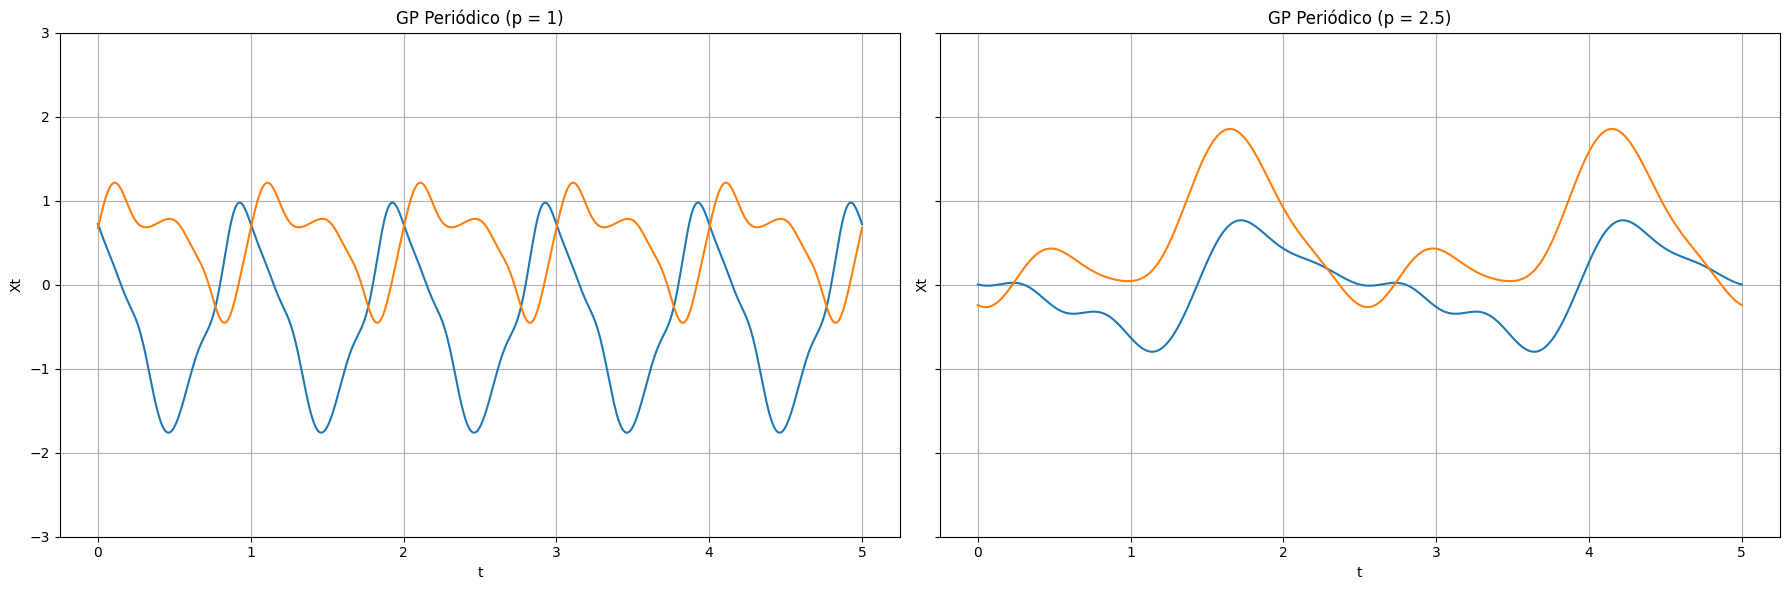

In [11]:
# COMPLETAR (PARA LA DIAPOSITIVA 74)
graficasfig, axs = plt.subplots(1,2,figsize=(18, 6), sharey=True)

period = [1, 2.5]
sigma_sq = 1
lengthscale = 1

for i, p in enumerate(period):
  samples = simular_GP_periodic(x, sigma_sq=sigma_sq, lengthscale=lengthscale, period=p, num_samples=2)
  for j in range(2):
    axs[i].plot(x, samples[j])
  axs[i].set_title(rf'GP Periódico (p = {p})')
  axs[i].set_ylabel('Xt')
  axs[i].set_xlabel('t')
  axs[i].grid(True)

axs[0].set_ylim(-3, 3)

plt.tight_layout()
plt.show()

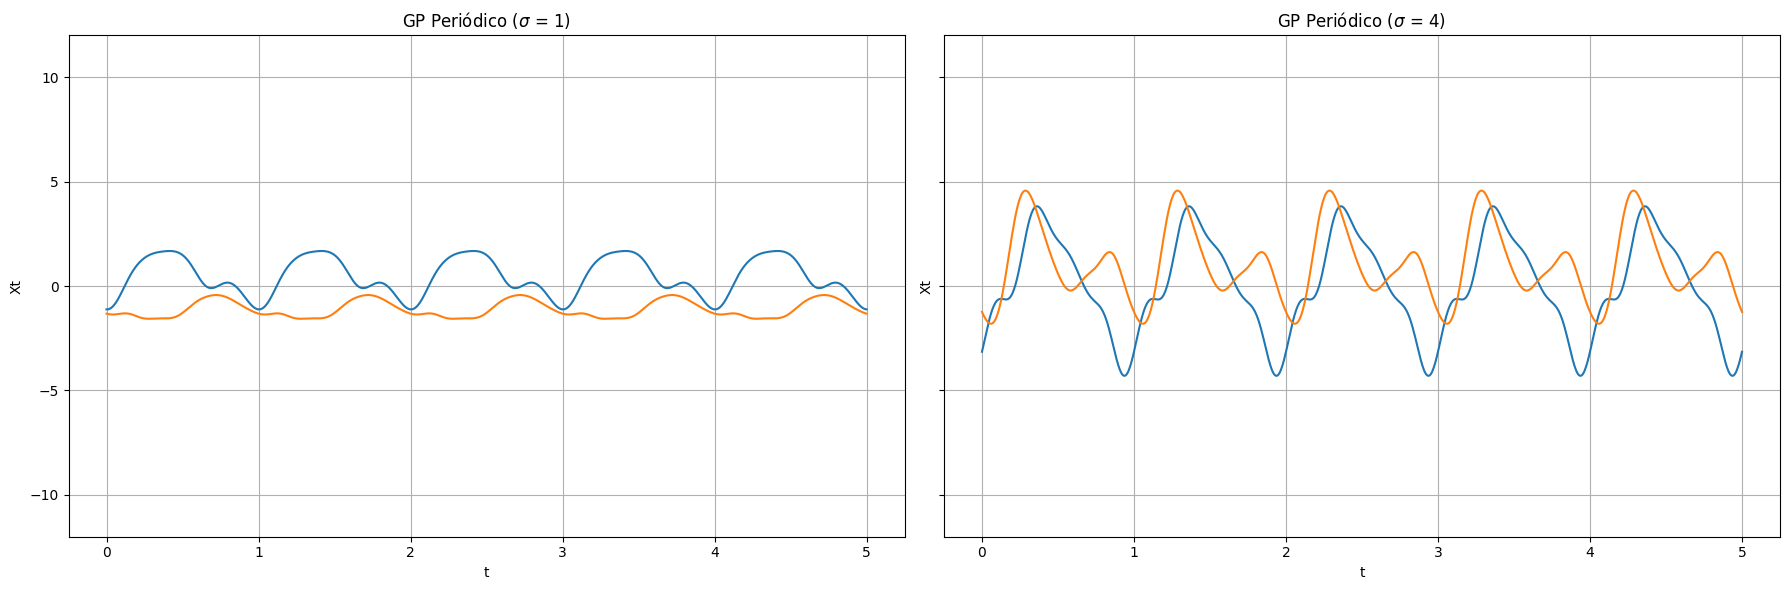

In [12]:
# COMPLETAR (PARA LA DIAPOSITIVA 76)
graficasfig, axs = plt.subplots(1,2,figsize=(18, 6), sharey=True)

period = 1
sigma = [1,4]
lengthscale=1

for i, s in enumerate(sigma):
  samples = simular_GP_periodic(x, sigma_sq=s**2, lengthscale=lengthscale, period=period, num_samples=2)
  for j in range(2):
    axs[i].plot(x, samples[j])
  axs[i].set_title(rf'GP Periódico ($σ$ = {s})')
  axs[i].set_ylabel('Xt')
  axs[i].set_xlabel('t')
  axs[i].grid(True)

axs[0].set_ylim(-12, 12)

plt.tight_layout()
plt.show()

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [24]:
def simular_GP_DPKpoly(t, degree=1, num_samples=1):
  """
  Simular un GP con kernel DPK con funciones base 1, t, ..., t^m.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  degree: grado máximo de los monomios utilizados. Int.
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """
  """
  #Hecho con la equivalencia de que las trayectorias son combinanciones lineales
  # de las funciones base con coeficientes siguiendo una N(0,1)


  # Vector de medias para los coeficientes
  vector_medias_coefs = np.zeros(degree + 1)
  # Matriz de covarianzas para los coeficientes
  matriz_covarianzas_coefs = np.eye(degree + 1)

  # Generar los coeficientes para cada muestra
  # shape (num_samples, degree + 1)
  coefs = np.random.multivariate_normal(vector_medias_coefs, matriz_covarianzas_coefs, num_samples)

  # Calcular las potencias de t
  # shape (n, degree + 1)
  potencias = np.array([t**i for i in range(degree + 1)]).T

  # Calcular las muestras: es el producto escalar de sus coeficientes
  # con las potencias.
  # shape (num_samples, n)
  samples = np.dot(coefs, potencias.T)
  """

  # Paso 1: calcula el vector de medias.
  vector_medias = np.zeros_like(t)   # Shape: (n,)


  # Paso 2: calcula la matriz de covarianzas.
  # [OPCIÓN 2: Usando el producto matricial F*F^T visto en la diapositiva 82]
  F = np.array([t**i for i in range(degree + 1)]).T
  matriz_covs = np.dot(F, F.T)

  # En cualquiera de las OPCIONES anteriores, la matriz de covarianzas resultante podría no ser semidefinida positiva (por problemas numéricos de redondeo).
  # Para resolverlo, es muy habitual y recomendable sumar un "jitter" o ruido definido positivo, es decir, sumar por ejemplo la identidad multplicada por un valor pequeño:
  matriz_covs = matriz_covs + 1e-9 * np.eye(len(t))

  # Paso 3: obtén las muestras/simulaciones del GP
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)



  return samples

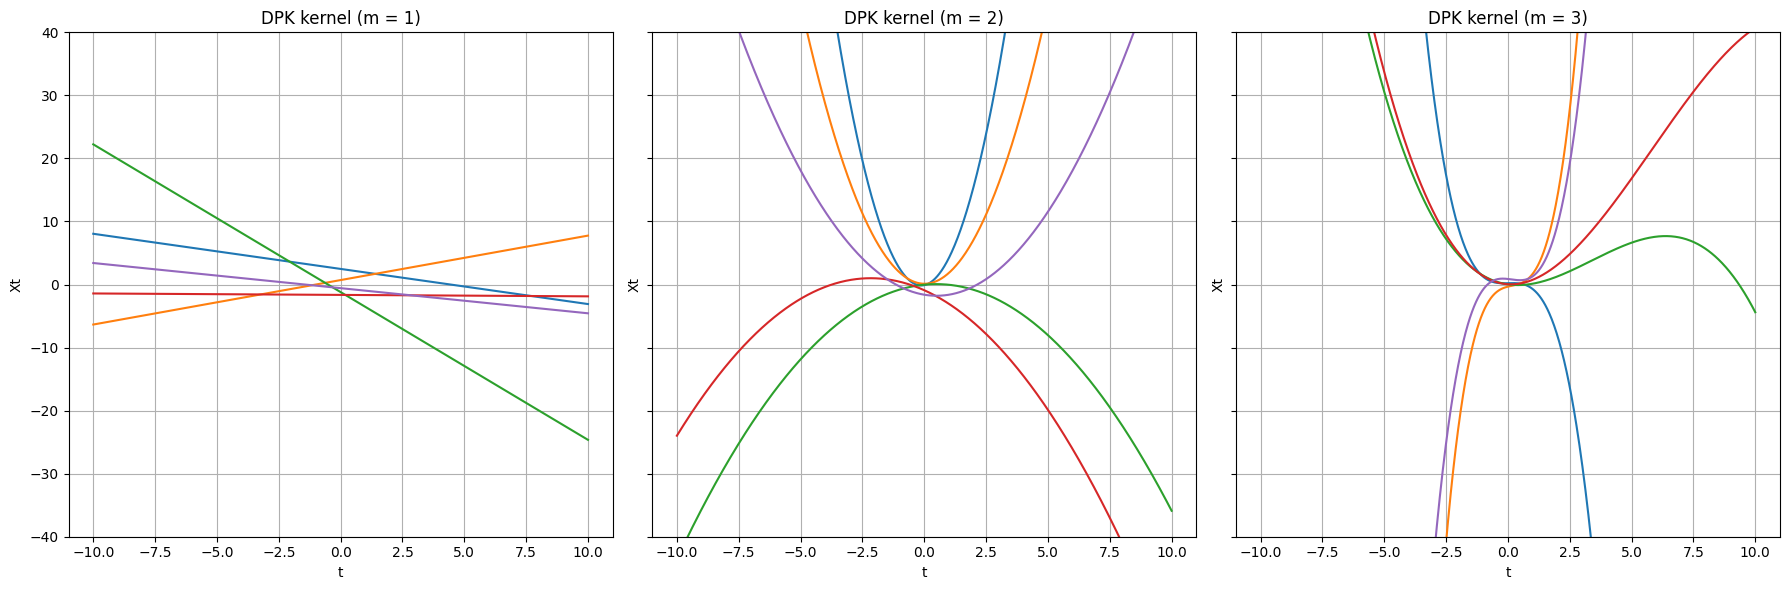

In [26]:
# COMPLETAR (PARA LA DIAPOSITIVA 89)
degree = [1,2,3]
graficasfig, axs = plt.subplots(1,len(degree),figsize=(18, 6), sharey=True)


n=1000
x=np.linspace(-10,10,n)

for i, d in enumerate(degree):
  samples = simular_GP_DPKpoly(x, degree=d, num_samples=5)
  for j in range(5):
    axs[i].plot(x, samples[j])
  axs[i].set_title(rf'DPK kernel (m = {d})')
  axs[i].set_ylabel('Xt')
  axs[i].set_xlabel('t')
  axs[i].grid(True)

axs[0].set_ylim(-40, 40)

plt.tight_layout()
plt.show()

## 5. Opcional: ¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?

Estas preguntas, bastante generales, se pueden abordar de muchas maneras. En esta sección se presenta muy brevemente una solución basada en el paradigma de programación orientada a objetos (POO). Es la manera más habitual de programar en Python y en muchos otros lenguajes.

La idea de la POO es estructurar el código usando el concepto de _clase_. Una _clase_ es algo ``parecido'' a un _struct_, que probablemente se viese en las asignaturas de C++, aunque una clase tiene mayor funcionalidad. Concretamente, una _clase_ es una estructura que nos permite crear objetos que contienen dos cosas principalmente:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación definimos una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.

In [27]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

En la celda anterior simplemente hemos definido "qué es un objeto de tipo RBF".

En la celda siguiente, utilizamos la clase recién definida para crear un objeto concreto de ese tipo:

In [28]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__ (es un método especial que se utiliza de esta manera)
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

<class '__main__.RBF'>
(100, 100)


A continuación definimos una clase para la función de medias constantemente igual a cero:

In [29]:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

Y creamos un objeto de ese tipo:

In [30]:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

<class '__main__.Zero_Mean_Function'>
(100,)
True


Definimos ahora una función ```simular_GP``` que recibe como parámetros __cualquier función de medias__ (```mf```) y __cualquier kernel__ (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [31]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para validar esta función, vamos a generar la imagen de la diapositiva 64, donde se usaba la función de medias identidad y el kernel RBF.

Para ello, definimos una clase para la función de medias identidad:

In [32]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, usamos esta clase, la clase RBF, y la función ```simular_GP``` para obtener lo buscado:

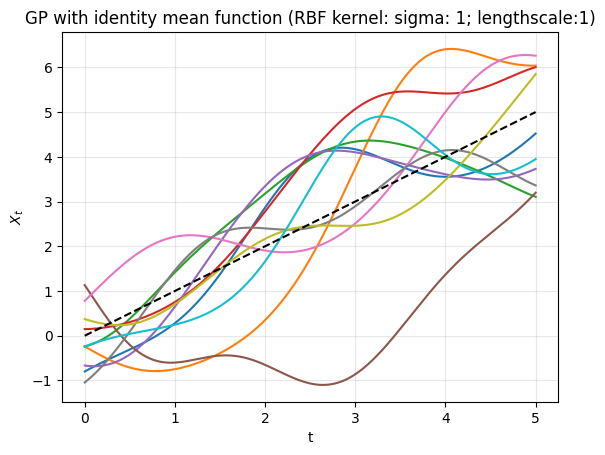

In [33]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: sigma: {sigma}; lengthscale:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()